In [13]:
# story z score shows story similarity, window z score schows window similarity, MIGHT need more data for fig 1f -- different windows' comparison

import numpy as np
import pandas as pd

scores = np.load('../scores/S1/perceived_movie/gpt_layer_9/laluna.npz', allow_pickle=True)
print(scores.files)
score_names = ['window_scores', 'window_zscores', 'story_scores', 'story_zscores']
score_files = {}
for name in score_names:
    score_files[name] = scores[name].item()

print(score_files['story_scores'])

['window_scores', 'window_zscores', 'story_scores', 'story_zscores']
{('laluna', 'WER'): np.float64(-0.04186400175476188), ('laluna', 'BLEU'): np.float64(0.15036660976157942), ('laluna', 'METEOR'): np.float64(0.1111510333551492), ('laluna', 'BERT'): np.float32(0.7932152)}


In [14]:
zscores = {'subject': [], 'gpt_layer': [], 'WER':[],'BLEU':[], 'METEOR':[], 'BERT':[]}
s_scores = {'subject': [], 'gpt_layer': [], 'WER':[],'BLEU':[], 'METEOR':[], 'BERT':[]}

for subject in ['S1','S2','S3']:
    for i in [6,7,8,9,10]:
        scores = np.load(f'../scores/{subject}/perceived_movie/gpt_layer_{i}/laluna.npz', allow_pickle=True)
        score_names = ['window_scores', 'window_zscores', 'story_scores', 'story_zscores']
        score_files = {}
        for name in score_names:
            score_files[name] = scores[name].item()
        print(score_files['story_scores'])
        print(score_files['story_zscores'])
        zscores['subject'].append(subject)
        s_scores['subject'].append(subject)
        zscores['gpt_layer'].append(i)
        s_scores['gpt_layer'].append(i)
        for k,v in score_files['story_zscores'].items():
            zscores[k[1]].append(v)
        for k,v in score_files['story_scores'].items():
            s_scores[k[1]].append(v)
        

{('laluna', 'WER'): np.float64(-0.037970860754222624), ('laluna', 'BLEU'): np.float64(0.1611570538172455), ('laluna', 'METEOR'): np.float64(0.11676984314598195), ('laluna', 'BERT'): np.float32(0.792568)}
{('laluna', 'WER'): np.float64(2.396832448147452), ('laluna', 'BLEU'): np.float64(3.8170329972466344), ('laluna', 'METEOR'): np.float64(4.19111120822221), ('laluna', 'BERT'): np.float32(4.8921537)}
{('laluna', 'WER'): np.float64(-0.0399978413829059), ('laluna', 'BLEU'): np.float64(0.14222085399635417), ('laluna', 'METEOR'): np.float64(0.10183816717145426), ('laluna', 'BERT'): np.float32(0.7902312)}
{('laluna', 'WER'): np.float64(1.7508409222713537), ('laluna', 'BLEU'): np.float64(1.514511714007313), ('laluna', 'METEOR'): np.float64(1.3792760856609976), ('laluna', 'BERT'): np.float32(3.553219)}
{('laluna', 'WER'): np.float64(-0.03935325172670741), ('laluna', 'BLEU'): np.float64(0.15347267432980824), ('laluna', 'METEOR'): np.float64(0.10521773759978903), ('laluna', 'BERT'): np.float32(0.

In [15]:
results_df = pd.DataFrame(zscores)

# WER correction
# results_df['WER'] = 1-results_df['WER']

results_df

,subject,gpt_layer,WER,BLEU,METEOR,BERT
0,S1,6,2.396832,3.817033,4.191111,4.892154
1,S1,7,1.750841,1.514512,1.379276,3.553219
2,S1,8,2.192204,2.862802,2.111034,4.759087
3,S1,9,2.818600,2.741409,3.018391,5.088041
4,S1,10,2.291909,4.164184,3.622310,6.092475
5,S2,6,3.347695,4.629075,4.813720,5.990136
6,S2,7,4.324753,3.161479,2.493980,6.885532
7,S2,8,4.061386,3.765706,4.121037,8.287516
8,S2,9,2.168734,3.242365,3.979652,8.074754
9,S2,10,3.041195,3.441555,4.073799,5.680726


In [16]:
results_df.rename(columns={'WER':'WER_zscore','BLEU':'BLEU_zscore', 'METEOR':'METEOR_zscore', 'BERT':'BERT_zscore'}, inplace=True)
results_df.to_csv('perceived_movie_zscores_gpt_layer.csv',index = False)

results_df

,subject,gpt_layer,WER_zscore,BLEU_zscore,METEOR_zscore,BERT_zscore
0,S1,6,2.396832,3.817033,4.191111,4.892154
1,S1,7,1.750841,1.514512,1.379276,3.553219
2,S1,8,2.192204,2.862802,2.111034,4.759087
3,S1,9,2.818600,2.741409,3.018391,5.088041
4,S1,10,2.291909,4.164184,3.622310,6.092475
5,S2,6,3.347695,4.629075,4.813720,5.990136
6,S2,7,4.324753,3.161479,2.493980,6.885532
7,S2,8,4.061386,3.765706,4.121037,8.287516
8,S2,9,2.168734,3.242365,3.979652,8.074754
9,S2,10,3.041195,3.441555,4.073799,5.680726


In [17]:
print(len(score_files['window_scores'][('wheretheressmoke', 'WER')]))

KeyError: ('wheretheressmoke', 'WER')

In [ ]:
results = np.load('results/S1/perceived_speech/wheretheressmoke.npz', allow_pickle=True)
result_names = results.files
result_files={}
for name in result_names:
    result_files[name] = results[name]
result_files

FileNotFoundError: [Errno 2] No such file or directory: 'results/S1/perceived_speech/wheretheressmoke.npz'

IndexError: index 1000 is out of bounds for axis 0 with size 1000

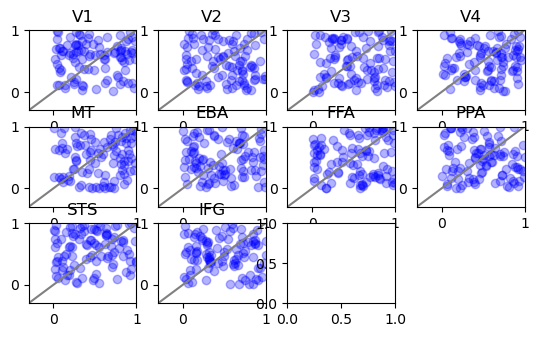

In [ ]:
from utils_ridge import util

util.plot_model_comparison_rois(np.random.rand(1000), np.random.rand(1000), "Model 1", "Model 2", [np.arange(100*i, 100*(i+1)) for i in range(16)], ["V1", "V2", "V3", "V4", "MT", "EBA", "FFA", "PPA", "STS", "IFG", "STG", "MTG", "Auditory", "Speech", "Semantic", "Motor"], thresh=0.35)
